In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# base dir
BASE_DIR = "/home/codezerro/Desktop/datasets"
# "/home/codezerro/Desktop/dataset_4_circuits/data" 

In [8]:
df = pd.read_csv(f"{BASE_DIR}/labels.csv")
df.columns

Index(['image', 'v', 'w'], dtype='object')

In [4]:
# linear velocity describe
# print(df["v"].describe())

In [5]:
# angular velocity describe
print(df["w"].describe())

count    84969.000000
mean        -0.029841
std          0.376109
min         -3.500000
25%         -0.129330
50%         -0.002370
75%          0.097480
max          3.000000
Name: w, dtype: float64


In [6]:
def categorize_w_v1(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.1:
        return "right"
    elif w <= 0.1:
        return "straight"
    elif w <= 1.0:
        return "left"
    elif w > 1.0:
        return "sharp_left"
    else:
        return "no actions"

def categorize_w_v2(w):
    if w < -1.5:
        return "sharp_right"
    elif w < -0.2:
        return "right"
    elif w <= 0.2:
        return "straight"
    elif w <= 1.5:
        return "left"
    elif w > 1.5:
        return "sharp_left"
    else:
        return "no actions"

In [7]:
df["w_category_v1"] = df["w"].apply(categorize_w_v1)
df["w_category_v2"] = df["w"].apply(categorize_w_v2)
print(df["w_category_v1"].value_counts())
print(df["w_category_v2"].value_counts())

w_category_v1
straight       39500
right          22933
left           19869
sharp_right     1628
sharp_left      1039
Name: count, dtype: int64
w_category_v2
straight       58754
right          14682
left           10556
sharp_right      635
sharp_left       342
Name: count, dtype: int64


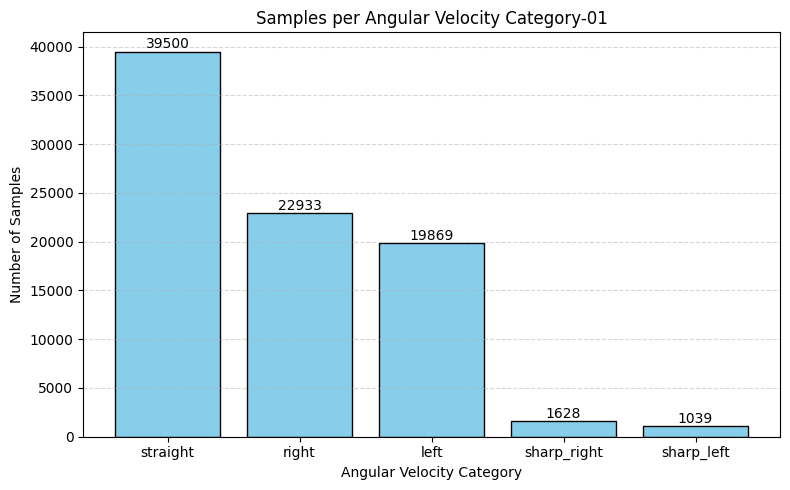

In [8]:
# Count samples per category
category_counts = df['w_category_v1'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title("Samples per Angular Velocity Category-01")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("angular_velocity_category_1.png")
plt.show()



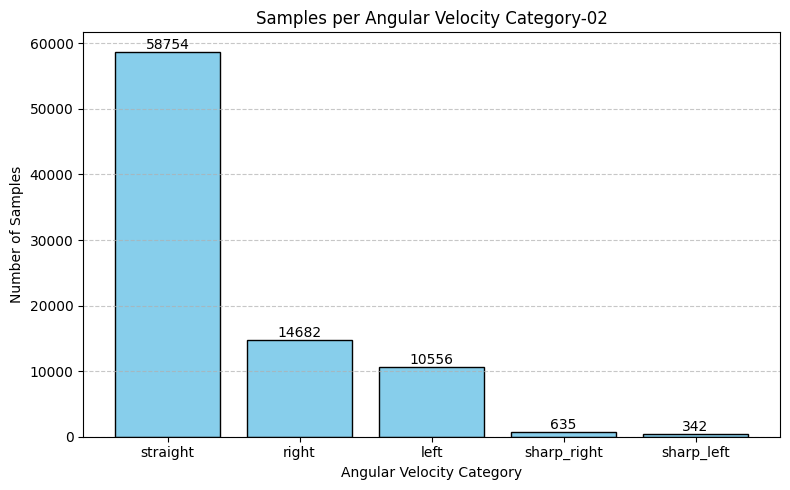

In [9]:
# Count samples per category
category_counts = df['w_category_v2'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title("Samples per Angular Velocity Category-02")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("angular_velocity_category_2.png")

plt.show()

In [10]:
# plot for category 1
# df["w_category_v1"].value_counts().plot(kind="bar", color="steelblue")
# plt.title("Angular Velocity (w) Category Distribution")
# plt.xlabel("w Category")
# plt.ylabel("Number of Samples")
# plt.grid(True)

# # Count samples per category
# category_counts = df_balanced['w_category'].value_counts()


# # plt.savefig("show.png")

# plt.show()

# # df["w_category_v1"][0]

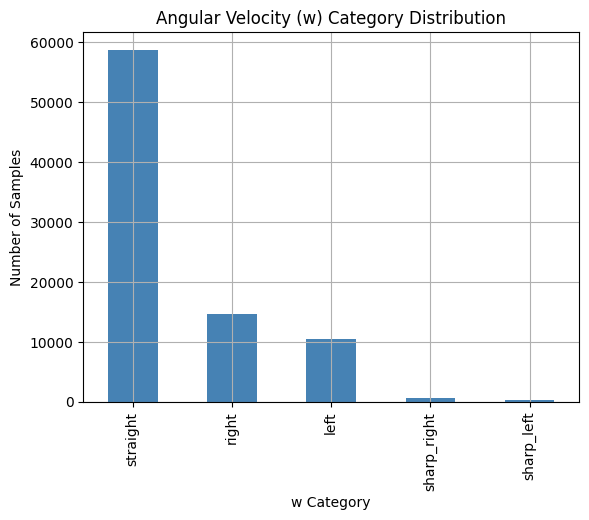

In [11]:
# plot for category 2
df["w_category_v2"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Angular Velocity (w) Category Distribution")
plt.xlabel("w Category")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()


In [12]:
# 

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

In [14]:
# base dir
BASE_DIR = "/home/codezerro/Desktop/datasets"
# "/home/codezerro/Desktop/datasets"

In [15]:
# Constants
CSV_PATH = f"{BASE_DIR}/labels.csv"
IMG_DIR = f"{BASE_DIR}"
IMAGE_SIZE = (640, 240)  # Resize for display
SAMPLES_PER_CATEGORY = 3  # You can change to show more/less

In [16]:
 # Load dataset
df = pd.read_csv(CSV_PATH, names=['image', 'v', 'w'])

In [17]:
# Define categories
# bins = [-float('inf'), -1.5, -0.2, 0.2, 1.5, float('inf')]
bins = [-float('inf'), -1.0, -0.1, 0.1, 1.0, float('inf')]
labels = ['Sharp Right', 'Right', 'Straight','Left', 'Sharp Left']

In [18]:
df['w'] = pd.to_numeric(df['w'], errors='coerce') 

In [19]:
df['w_category'] = pd.cut(df['w'], bins=bins, labels=labels)

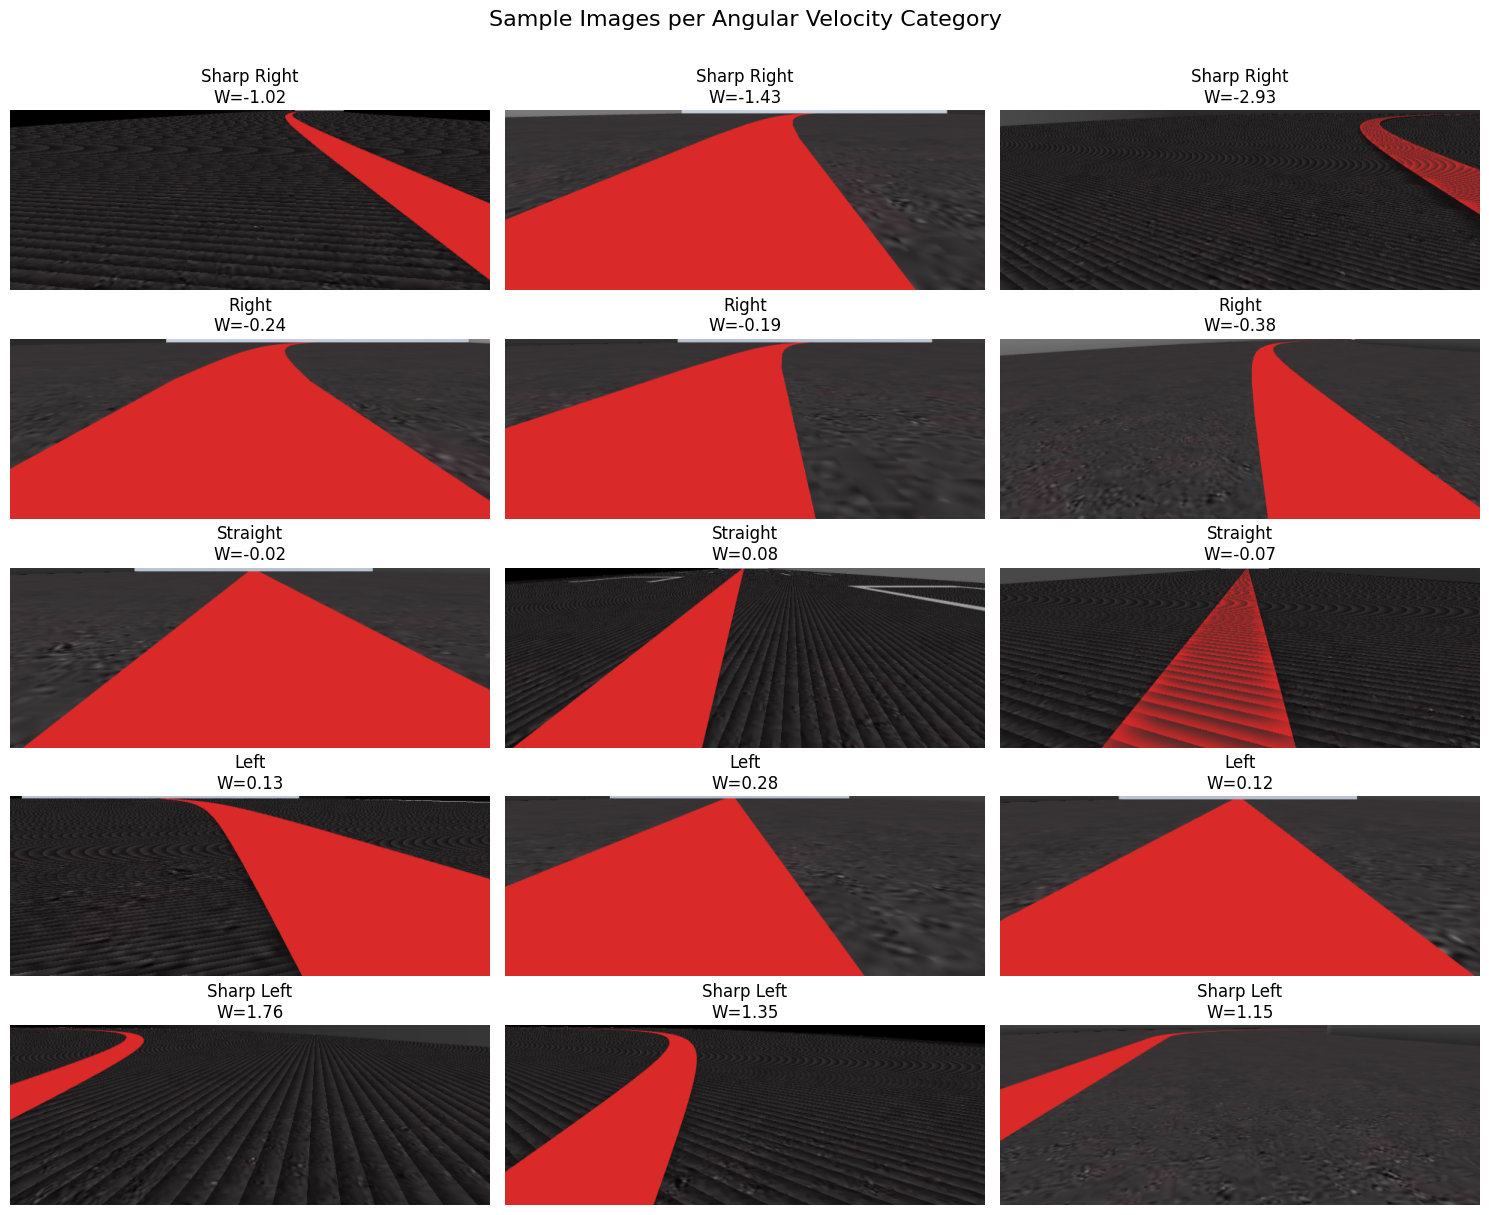

In [20]:

# Create subplots
fig, axes = plt.subplots(len(labels), SAMPLES_PER_CATEGORY, figsize=(SAMPLES_PER_CATEGORY*5, len(labels)*2.5))
fig.suptitle("Sample Images per Angular Velocity Category", fontsize=16)

# Loop through each category
for row_idx, category in enumerate(labels):
    # Get random N samples from this category
    samples = df[df['w_category'] == category].sample(min(SAMPLES_PER_CATEGORY, df['w_category'].value_counts().get(category, 0)))

    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(IMG_DIR, row['image'])

        # Read and resize image
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMAGE_SIZE)

            ax = axes[row_idx, col_idx] if SAMPLES_PER_CATEGORY > 1 else axes[row_idx]
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"{category}\nW={row['w']:.2f}")
        else:
            print(f"Image not found: {img_path}")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("angular_velocity_category_image_samples.png")
plt.show()
